# RANDOM FOREST EXPERIMENTATION

In [7]:
from HelperFunctions import shift_axis
import matplotlib.pyplot as plt
import h5py
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize

In [8]:
def load_and_preprocess(filename, transform=False):
    with h5py.File(filename, 'r') as hf:
        X = hf['y_values'][:]
        y = hf['num_peaks'][:]
    
    if transform:
        print(f"Applying shift_axis transformation to {filename}...")
        X = np.array([shift_axis(spectrum, resolution=200) for spectrum in X])
    
    return X, y

Applying shift_axis transformation to training_data/raman_training.h5...
Applying shift_axis transformation to training_data/raman_test.h5...

--- Training Random Forest on Shifted Spectra ---
Accuracy (Shifted): 0.4057


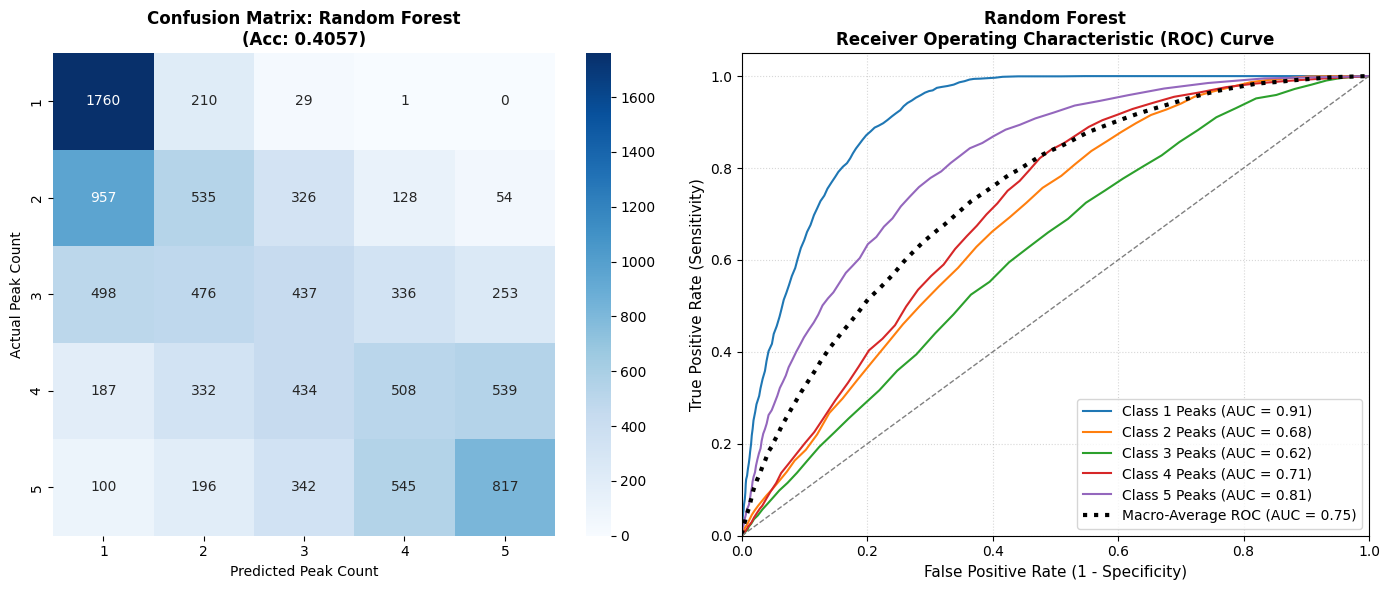

In [10]:
# --- 1. Load Preprocessed Data (Shifted Only) ---
X_train_shift, y_train = load_and_preprocess("training_data/raman_training.h5", transform=True)
X_test_shift, y_test = load_and_preprocess("training_data/raman_test.h5", transform=True)

# Identify unique peak counts (classes) present in your target labels
classes = np.unique(y_train)
n_classes = len(classes)

# Binarize labels for multi-class OVR (One-vs-Rest) ROC analysis
y_test_binarized = label_binarize(y_test, classes=classes)

# --- 2. Train Random Forest Model ---
print("\n--- Training Random Forest on Shifted Spectra ---")
rf_shift = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42, criterion='gini')
rf_shift.fit(X_train_shift, y_train)

# Get hard predictions for Accuracy/Confusion Matrix and probabilities for ROC
y_pred_shift = rf_shift.predict(X_test_shift)
y_score_shift = rf_shift.predict_proba(X_test_shift)

acc_shift = accuracy_score(y_test, y_pred_shift)
print(f"Accuracy (Shifted): {acc_shift:.4f}")

# --- 3. Comparative Visualization Layout ---
plt.figure(figsize=(14, 6))

# Subplot 1: Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred_shift)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title(f"Confusion Matrix: Random Forest\n(Acc: {acc_shift:.4f})", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Peak Count")
plt.ylabel("Actual Peak Count")

# Subplot 2: Multi-Class & Mean ROC Curves
plt.subplot(1, 2, 2)

# Compute and plot ROC curve and ROC area for each individual peak class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_label in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score_shift[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=1.5,
             label=f'Class {class_label} Peaks (AUC = {roc_auc[i]:.2f})')

# Compute Macro-Average ROC curve
# 1. Aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# 2. Interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# 3. Average it and compute AUC
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot the Macro-Average ROC curve
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-Average ROC (AUC = {roc_auc["macro"]:.2f})',
         color='black', linestyle=':', linewidth=3)

# Plot baseline reference line
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)

# Formatting the ROC plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('Random Forest\nReceiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
plt.legend(loc="lower right", fontsize=10, framealpha=0.8)
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()

# 1. Save the two-panel figure to disk (dpi=300 ensures crisp, publication-quality text)
plt.savefig("shifted_spectra_evaluation.png", dpi=300, bbox_inches='tight')

# 2. Display the figure on screen
plt.show()

In [11]:
import numpy as np

# 1. Get prediction probabilities for the test set (using the shifted model)
# Shape will be: (n_samples, n_classes)
y_score_shift = rf_shift.predict_proba(X_test_shift)

# 2. Get the actual class names/labels mapped to the probability columns
# RandomForestClassifier stores classes alphabetically/numerically in .classes_
model_classes = rf_shift.classes_

# 3. Find the indices of the top 3 highest probabilities for each sample
# np.argsort sorts ascending, so [-3:] grabs the 3 largest values, 
# and [::-1] reverses it so the most confident is first.
top_3_indices = np.argsort(y_score_shift, axis=1)[:, -3:][:, ::-1]

# 4. Map those indices back to the actual peak count labels
top_3_labels = model_classes[top_3_indices]

# 5. Check if the true label matches any of the top 3 predictions for each row
# np.any(..., axis=1) checks horizontally across the 3 choices
is_true_in_top_3 = np.any(top_3_labels == y_test[:, np.newaxis], axis=1)

# 6. Calculate and print the percentage
top_3_accuracy = np.mean(is_true_in_top_3) * 100

print(f"Top-3 Accuracy: {top_3_accuracy:.2f}%")
print(f"The true peak count was in the top 3 choices in {np.sum(is_true_in_top_3)} out of {len(y_test)} test cases.")

Top-3 Accuracy: 87.02%
The true peak count was in the top 3 choices in 8702 out of 10000 test cases.
